In [37]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [38]:
# import like this
items_path = "data/20_data/items.csv"
q1_path = "data/20_data/quarter-1.csv"
q2_path = "data/20_data/quarter-2.csv"
q3_path = "data/20_data/quarter-3.csv"


q1= pd.read_csv(q1_path)
q2 = pd.read_csv(q2_path)
q3 = pd.read_csv(q3_path)
items = pd.read_csv(items_path)

### `Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [39]:
# code here
df = pd.concat([q1, q2, q3], keys=["Q-1", "Q-2", "Q-3"], axis='index').reset_index()\
    .merge(items, on='item_id', how='inner').drop(columns=['level_1']).rename(columns={"level_0":"Quarter"})
df["quantity"] = df['quantity'].astype('int')
df.groupby(["Quarter", "item_name"])['quantity'].sum().reset_index().groupby("Quarter").apply(lambda x: x.nlargest(1, 'quantity', keep='all'))

,,item_name,quantity
Quarter,,,
Q-1,17,Chicken Bowl,367
Q-2,65,Chicken Bowl,394


In [40]:
df["item_price"] = df["item_price"].str.replace('$', "").astype(float)

In [41]:

df.groupby(["Quarter", "item_name"])["item_price"].sum().reset_index()\
    .groupby('Quarter').apply(lambda x: x.nlargest(1, 'item_price', keep='all'))

,,item_name,item_price
Quarter,,,
Q-1,17,Chicken Bowl,3525.72
Q-2,65,Chicken Bowl,3817.01


In [42]:
revenue = df.groupby('Quarter')['item_price'].sum()
orders = df.groupby("Quarter")["quantity"].count()
avg_price_order = revenue/orders
print(avg_price_order)
df.groupby('Quarter')['item_price'].mean()

Quarter
Q-1    7.577138
Q-2    7.354994
dtype: float64


Quarter
Q-1    7.577138
Q-2    7.354994
Name: item_price, dtype: float64

### `Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap.*


In [43]:
# code here
deli = pd.read_csv("data/20_data/deliveries.csv")
match = pd.read_csv("data/20_data/matches.csv")

In [44]:
ipl = pd.merge(match, deli, left_on="id", right_on="match_id", how="inner")
pd.options.display.max_columns = None
def fun(row):
    if type(row)==str:
        return 1
    else:
        return 0

ipl["is_out"] = ipl["player_dismissed"].apply(fun)

def ra(group):
    return group.nlargest(1, "is_out", keep='all')

ipl.groupby(["season", "bowler"])["is_out"].sum().reset_index().groupby("season").apply(ra)\
    .sort_index().reset_index(level=0).set_index('season').rename(columns={'is_out':"wickets"})

,bowler,wickets
season,,
2008,Sohail Tanvir,24
2009,RP Singh,26
2010,PP Ojha,22
2011,SL Malinga,30
2012,M Morkel,30
2013,DJ Bravo,34
2014,MM Sharma,26
2015,DJ Bravo,28
2016,B Kumar,24


### `Q-7:` Best bowler in death overs.

Death Overs - [16-20]

In [45]:
# code here

fil = ipl[ipl["over"]>15]
fil.groupby(["season", "bowler"])["is_out"].sum().reset_index().groupby("season").apply(ra).sort_index().reset_index(level=0).set_index('season').rename(columns={'is_out':"wickets"})

,bowler,wickets
season,,
2008,Sohail Tanvir,18
2009,SL Malinga,16
2010,IK Pathan,10
2010,SL Malinga,10
2011,SL Malinga,16
2012,SP Narine,21
2013,DJ Bravo,25
2014,MM Sharma,16
2015,DJ Bravo,24


## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [46]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")


### `Q-8:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm


In [47]:
df = pd.concat([sepal_all, petal_all], axis='columns').drop(columns=["Unnamed: 0"])

a = list(df.columns)
a[0] = "remove"
df.columns = a

In [48]:
df = df.drop(columns=["remove"])

In [49]:
specie = pd.concat([virginica, versicolor, setosa])
dff = specie.merge(df, on="Id", how="inner").sort_values(by="Id").drop(columns=["Unnamed: 0"])

In [50]:
df = dff

### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

<Axes: xlabel='Species'>

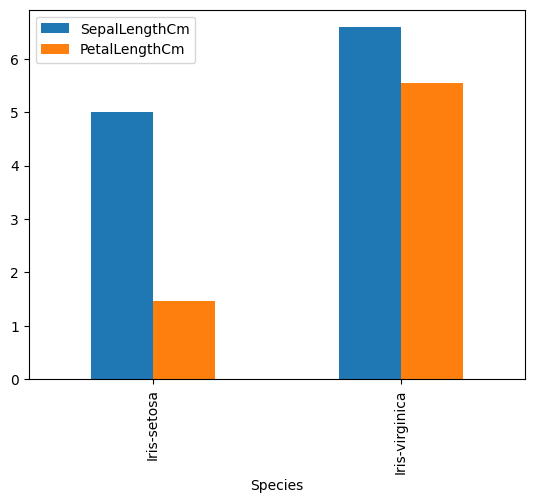

In [ ]:
# code here

fil = df[df["Species"].isin(["Iris-setosa", "Iris-virginica"])]
fil.groupby('Species')[["SepalLengthCm", "PetalLengthCm"]].mean().plot(kind='bar')

In [52]:
# code here

### `Q-10:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [63]:
# code here
d = df.groupby("Species")["SepalWidthCm"].agg(['max', 'min'])

print(f"maximium Sepal width of {d.index[0]} is {d['max'].iloc[0]}")
print(f"manimium Sepal width of {d.index[0]} is {d['min'].iloc[0]}")
print("*"*50)
print(f"maximium Sepal width of {d.index[1]} is {d['max'].iloc[1]}")
print(f"manimium Sepal width of {d.index[1]} is {d['min'].iloc[1]}")


maximium Sepal width of Iris-setosa is 4.4
manimium Sepal width of Iris-setosa is 2.3
**************************************************
maximium Sepal width of Iris-versicolor is 3.4
manimium Sepal width of Iris-versicolor is 2.0
